## Machine learning with `g.ml`: functions, graphs, training

`g.ml` builds networks from **learnable functions** (`g.ml.function`) that are composed into larger functions with **symbolic graphs**, and trains them with GPT's optimizers through the reverse automatic differentiation (see the `ad-reverse` tutorial).

In this tutorial we learn a gauge-covariant map of a matrix field: given the plaquette loop sum $P(x)$ through the links in direction $\mu$, which transforms as $P(x) \to V(x) P(x) V(x)^\dagger$, we train a network $f$ with $f(V P V^\dagger) = V f(P) V^\dagger$ to reproduce a teacher $f^*(P) = P + 0.3 P^2 - 0.2 P P^\dagger P$.

### Setup

We import the libraries

In [1]:
import gpt as g
import numpy as np
import matplotlib.pyplot as plt

and set up a random number generator, a small grid, and a gauge field

In [2]:
rng = g.random("ml-tutorial")
grid = g.grid([4, 4, 4, 4], g.double)
rad = g.ad.reverse

U = g.qcd.gauge.random(grid, rng, scale=0.5)

GPT :       0.193077 s : Initializing gpt.random(ml-tutorial,vectorized_ranlux24_389_64) took 0.000138521 s


The training data are the loop sums $P_\mu(x) = \rho \sum_{\nu \neq \mu} (\text{plaquettes through the link } (x, \mu))$ for all four directions, computed with a weighted parallel transport

In [3]:
rho = 0.1


def loop_sum(U, mu):
    description = [(rho, g.path().f(nu).f(mu).b(nu).b(mu)) for nu in range(4) if nu != mu] + [
        (rho, g.path().b(nu).f(mu).f(nu).b(mu)) for nu in range(4) if nu != mu
    ]
    pt, _ = g.parallel_transport_weighted(U, description)
    return g(sum(pt(U)))


P = [loop_sum(U, mu) for mu in range(4)]
T = [g(p + 0.3 * p * p - 0.2 * p * g.adj(p) * p) for p in P]

### A learnable function

A `g.ml.function` maps named **inputs** to named **outputs**. It owns named **parameters** (trained) and **constants** (fixed). A subclass declares the slots in its constructor and implements `initialize` (separate from construction) and `evaluate`. Here is a minimal covariant function $y = x + c_1 x x + c_2 x x^\dagger x$ with two complex numbers as parameters:

In [4]:
class polynomial(g.ml.function):
    def __init__(self, template):
        super().__init__(
            inputs=[("x", template)],
            outputs=[("y", template)],
            parameters=[("c", [0j, 0j])],  # a list slot: elements c.0 and c.1
        )

    def initialize(self, rng):
        self["c"] = [0.1 + 0j, 0.0j]

    def evaluate(self, inputs, parameters, constants):
        (x,) = inputs
        (c,) = parameters
        return [g(x + c[0] * x * x + c[1] * x * g.adj(x) * x)]


f = polynomial(P[0])
f.initialize(rng)
print(f.parameter_names(), f["c.0"], f.parameters())

['c.0', 'c.1'] (0.1+0j) [(0.1+0j), 0j]


A function is called on a list of inputs and returns a list of outputs. Called with nodes, e.g. leaves of a training graph passed as `parameters`, the same code builds an AD graph:

In [5]:
(y,) = f([P[0]])
print(g.norm2(y - T[0]) / g.norm2(T[0] - P[0]))

0.22669176184926565


### Building a network from symbols

Larger functions are built by calling functions on **symbols**. Each call records a node of the graph and returns symbols for its outputs. Every call has a **name**, which prefixes the names of its parameters in the composite. `g.ml.pack` names the outputs, and `.function()` turns the graph into a new `g.ml.function`.

We use the layers of `g.ml.layer`:
- `replicate` makes $C$ channels $X_c = P$;
- `local_covariant_matrix` is a residual block on the channels, $X_c \to X_c + Y_c Y_{c+1}$ with $Y_c = \sum_d (a_{cd} X_d + b_{cd} X_d^\dagger) + \beta_c$;
- `linear_combination` is the readout $f = P + \sum_c w_c X_c$.

The same block is applied twice, so its weights are **shared** between the two calls:

In [6]:
C = 2
replicate = g.ml.layer.replicate(P[0], C)
block = g.ml.layer.local_covariant_matrix(P[0], C)
readout = g.ml.layer.linear_combination(P[0], C)

(x,) = g.ml.symbols("P")
(X,) = replicate([x])
(X1,) = block([X], name="layer0")
(X2,) = block([X1], name="layer1")  # the same block again: shared weights
(y,) = readout([x, X2], name=r"$\oplus$")
net = g.ml.pack(f=y).function()
net.initialize(rng)

`describe()` lists the graph: one line per call with its arguments and the parameters it uses, by their names in the composite. The second call of the shared block uses the parameters named after its first call:

In [7]:
print(net.describe())

inputs: P
  replicate = replicate(x=P)
  layer0    = local_covariant_matrix(X=replicate.X)  parameters: layer0.a.0, layer0.a.1, layer0.a.2, layer0.a.3, layer0.b.0, layer0.b.1, layer0.b.2, layer0.b.3, layer0.beta.0, layer0.beta.1
  layer1    = local_covariant_matrix(X=layer0.X)     parameters: layer0.a.0, layer0.a.1, layer0.a.2, layer0.a.3, layer0.b.0, layer0.b.1, layer0.b.2, layer0.b.3, layer0.beta.0, layer0.beta.1
  $\oplus$  = linear_combination(x=P, X=layer1.X)    parameters: $\oplus$.w.0, $\oplus$.w.1
outputs: f=$\oplus$.y


`draw()` shows the same graph with matplotlib: inputs on the left, outputs on the right, a box per call (name and function class) with edges entering at the ports of their slots. The two calls of the shared block have a common border color, and the second one names the call it shares with:


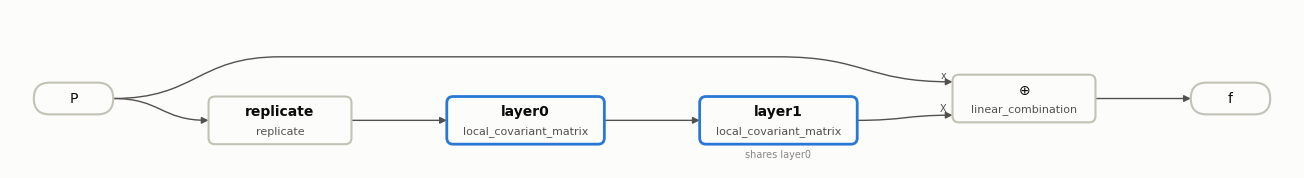

In [8]:
net.draw();


For figures in a paper, each call can carry a `label` (display only; matplotlib mathtext is allowed), which is drawn instead of the name and class. Labels are given at the call, so here we build the same network once more from the same layer instances (composites share their functions, and hence the weights):


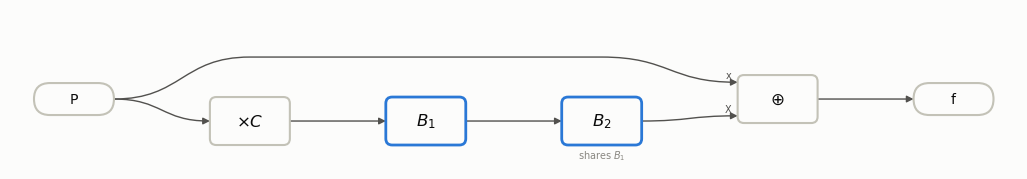

In [9]:
(xl,) = g.ml.symbols("P")
(Xl,) = replicate([xl], label=r"$\times C$")
(Xl,) = block([Xl], name="layer0", label=r"$B_1$")
(Xl,) = block([Xl], name="layer1", label=r"$B_2$")
(yl,) = readout([xl, Xl], label=r"$\oplus$")
g.ml.pack(f=yl).draw();


Unnamed calls are named after their class. Two such calls in one graph must be named explicitly:

In [10]:
(z,) = g.ml.symbols("z")
(a,) = polynomial(P[0])([z])
(b,) = polynomial(P[0])([a])
try:
    g.ml.pack(b=b).function()
except ValueError as e:
    print(e)

Duplicate call names ['polynomial']: name the calls (name=...)


The composite's parameters are addressed by hierarchical names. A composite holds no values of its own: it reads and writes its functions' storage, so `net["layer0.a.1"]` and `block["a.1"]` are the same parameter

In [11]:
print(len(net.parameters()), net.parameter_names()[:5], "...")
print(net["layer0.a.1"] == block["a.1"], net["layer1.a.1"] == block["a.1"])

12 ['layer0.a.0', 'layer0.a.1', 'layer0.a.2', 'layer0.a.3', 'layer0.b.0'] ...
True True


### Gauge covariance

Every operation of the network is covariant, so $f(V P V^\dagger) = V f(P) V^\dagger$ up to rounding:

In [12]:
V = rng.element(g.mcolor(grid))
f0 = net([P[0]])[0]
f1 = net([g(V * P[0] * g.adj(V))])[0]
print(g.norm2(f1 - V * f0 * g.adj(V)) / g.norm2(f0))

4.954526829015894e-32


### Training

The loss compares the network with the teacher on all four directions, normalized to the non-trivial part of the teacher (1 for $f = $ identity):

$$L = \frac{\sum_\mu |f(P_\mu) - T_\mu|^2}{\sum_\mu |T_\mu - P_\mu|^2}$$

We build its graph **once**, with node leaves for the parameters, and wrap it as a functional of the parameters. GPT's optimizers and the gradient check work on such functionals:

In [13]:
leaves = [rad.node(w) for w in net.parameters()]
norm = sum(g.norm2(g(t - p)) for p, t in zip(P, T))
loss = sum(g.norm2(net([rad.node(p, with_gradient=False)], leaves)[0] - t) for p, t in zip(P, T))
loss = (loss * (1.0 / norm)).functional(*leaves)

loss.assert_gradient_error(rng, net.parameters(), net.parameters(), 1e-4, 1e-8)

GPT :       0.306252 s : Test that functional is real: 0.0


GPT :       0.332579 s : Assert gradient error: 4.5342993290766175e-13 < 1e-08


Adam updates `net.parameters()` in place, i.e. the storage of the layers. We train in rounds of 10 steps (with Adam's log messages switched off) and record the loss:

In [14]:
g.default.set_verbose("adam", False)
opt = g.algorithms.optimize.adam(maxiter=10, alpha=5e-3, eps=1e-15, log_functional_every=100)
history = [loss(net.parameters())]
for r in range(20):
    opt(loss)(net.parameters(), net.parameters())
    history.append(loss(net.parameters()))
print(f"loss {history[0]:.3e} -> {history[-1]:.3e}")

loss 1.401e+00 -> 6.208e-03


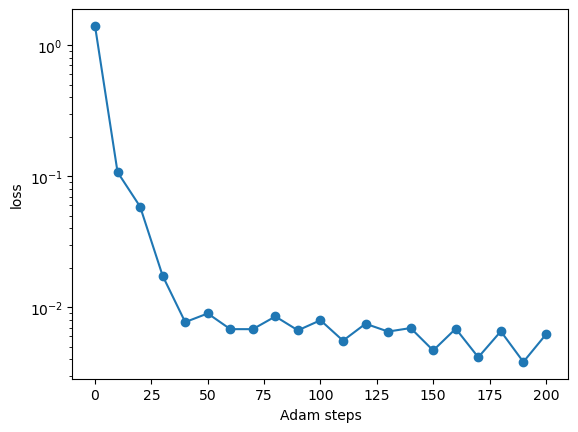

In [15]:
plt.semilogy(10 * np.arange(len(history)), history, "o-")
plt.xlabel("Adam steps")
plt.ylabel("loss")
plt.show()

### Sharing functions between composites

The symbols of a graph can be packed into several functions. They share the functions, and hence the trained values. Here the network after the first block only:

In [16]:
first = g.ml.pack(X1=X1).function()
print(first.describe())
X1_value = first([P[0]])[0]
print(first.parameter_names()[:3], "...", first["layer0.a.1"] == net["layer0.a.1"])

inputs: P
  replicate = replicate(x=P)
  layer0    = local_covariant_matrix(X=replicate.X)  parameters: layer0.a.0, layer0.a.1, layer0.a.2, layer0.a.3, layer0.b.0, layer0.b.1, layer0.b.2, layer0.b.3, layer0.beta.0, layer0.beta.1
outputs: X1=layer0.X
['layer0.a.0', 'layer0.a.1', 'layer0.a.2'] ... True


### Next steps

- Larger graphs in `draw()`: a symbol (`y.draw()`) or a `g.ml.pack` draws the part of the graph it depends on; nested composites are single boxes (draw them directly to see inside).
- Gates (`local_covariant_matrix(..., gate=True)`) with references set by `net.calibrate(samples)`.
- Trained functions inside GPT's actions, e.g. as `loop_function` of `directional_parallel_transport` (see `tests/ml/loop_function.py`).